# Tomato Leaf Disease Detection with Deep Learning and Grad-CAM

In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

2026-09-24 22:28:45.578966: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-24 22:28:45.579076: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-24 22:28:45.741633: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow version: 2.15.0
GPU available: True


In [2]:
DATA_DIR = None
base_dir = "/kaggle/input"

for root, dirs, files in os.walk(base_dir):
    # don't descend into grayscale/segmented at all
    dirs[:] = [d for d in dirs if d.lower() not in ("grayscale", "segmented")]

    tomato_folders = [d for d in dirs if d.lower().startswith("tomato")]
    if len(tomato_folders) >= 5:
        DATA_DIR = root
        break

print("Dataset folder found:", DATA_DIR)

Dataset folder found: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/plantvillage dataset/color



PlantVillage has 14 crops. To keep the project focused and fast, we use **only tomato leaves** (about 10 classes: healthy plus 9 diseases, roughly 18,000 images).

We split the images of **each class** into three groups and copy them into separate folders:

- **Training set (70%):** the model learns from these.
- **Validation set (15%):** used to check progress during training.
- **Test set (15%):** kept aside and used **only once at the end** for the final, honest result.

Putting them in separate folders guarantees that no image ends up in more than one set. The `seed=42` makes the split the same every time you run it. This cell takes about 2–3 minutes.

In [3]:
import random
from tqdm import tqdm

WORK_DIR = "/kaggle/working/tomato_data"
tomato_classes = sorted([d for d in os.listdir(DATA_DIR) if d.lower().startswith("tomato")])

random.seed(42)

for c in tomato_classes:
    files = sorted(os.listdir(os.path.join(DATA_DIR, c)))
    random.shuffle(files)

    n_train = int(0.70 * len(files))
    n_val = int(0.15 * len(files))

    splits = {
        "train": files[:n_train],
        "val": files[n_train:n_train + n_val],
        "test": files[n_train + n_val:],
    }

    for split_name, split_files in splits.items():
        folder = os.path.join(WORK_DIR, split_name, c)
        os.makedirs(folder, exist_ok=True)
        for f in tqdm(split_files, desc=f"{c} -> {split_name}", leave=False):
            shutil.copy(os.path.join(DATA_DIR, c, f), folder)

print("Number of tomato classes:", len(tomato_classes))
for c in tomato_classes:
    print(" -", c)

for split_name in ["train", "val", "test"]:
    total = sum(len(os.listdir(os.path.join(WORK_DIR, split_name, c))) for c in tomato_classes)
    print(f"{split_name}: {total} images")

Number of tomato classes: 10
 - Tomato___Bacterial_spot
 - Tomato___Early_blight
 - Tomato___Late_blight
 - Tomato___Leaf_Mold
 - Tomato___Septoria_leaf_spot
 - Tomato___Spider_mites Two-spotted_spider_mite
 - Tomato___Target_Spot
 - Tomato___Tomato_Yellow_Leaf_Curl_Virus
 - Tomato___Tomato_mosaic_virus
 - Tomato___healthy
train: 12707 images
val: 2719 images
test: 2734 images


Total images: 18160
                                        Class  Images
       Tomato___Tomato_Yellow_Leaf_Curl_Virus    5357
                      Tomato___Bacterial_spot    2127
                         Tomato___Late_blight    1909
                  Tomato___Septoria_leaf_spot    1771
Tomato___Spider_mites Two-spotted_spider_mite    1676
                             Tomato___healthy    1591
                         Tomato___Target_Spot    1404
                        Tomato___Early_blight    1000
                           Tomato___Leaf_Mold     952
                 Tomato___Tomato_mosaic_virus     373


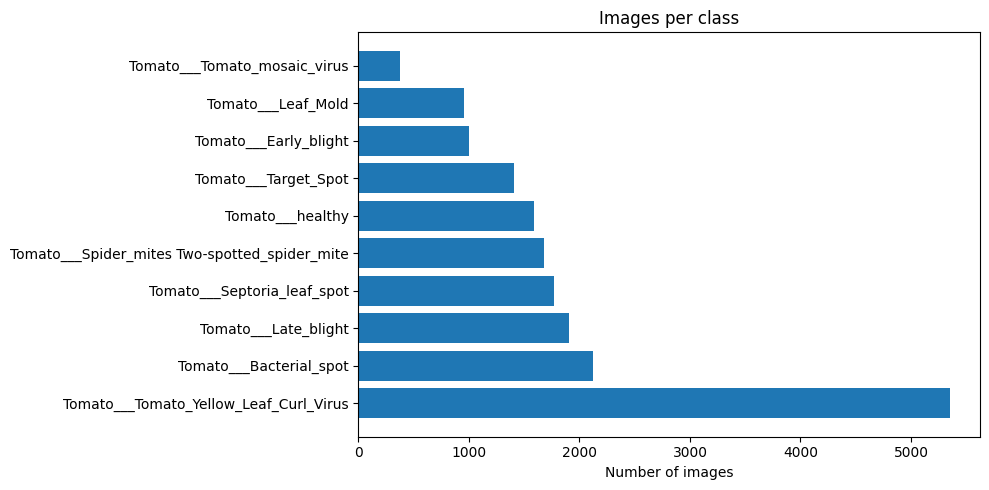

In [4]:
counts = {c: len(os.listdir(os.path.join(DATA_DIR, c))) for c in tomato_classes}
counts_df = pd.DataFrame(list(counts.items()), columns=["Class", "Images"])
counts_df = counts_df.sort_values("Images", ascending=False)

print("Total images:", counts_df["Images"].sum())
print(counts_df.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(counts_df["Class"], counts_df["Images"])
plt.xlabel("Number of images")
plt.title("Images per class")
plt.tight_layout()
plt.show()

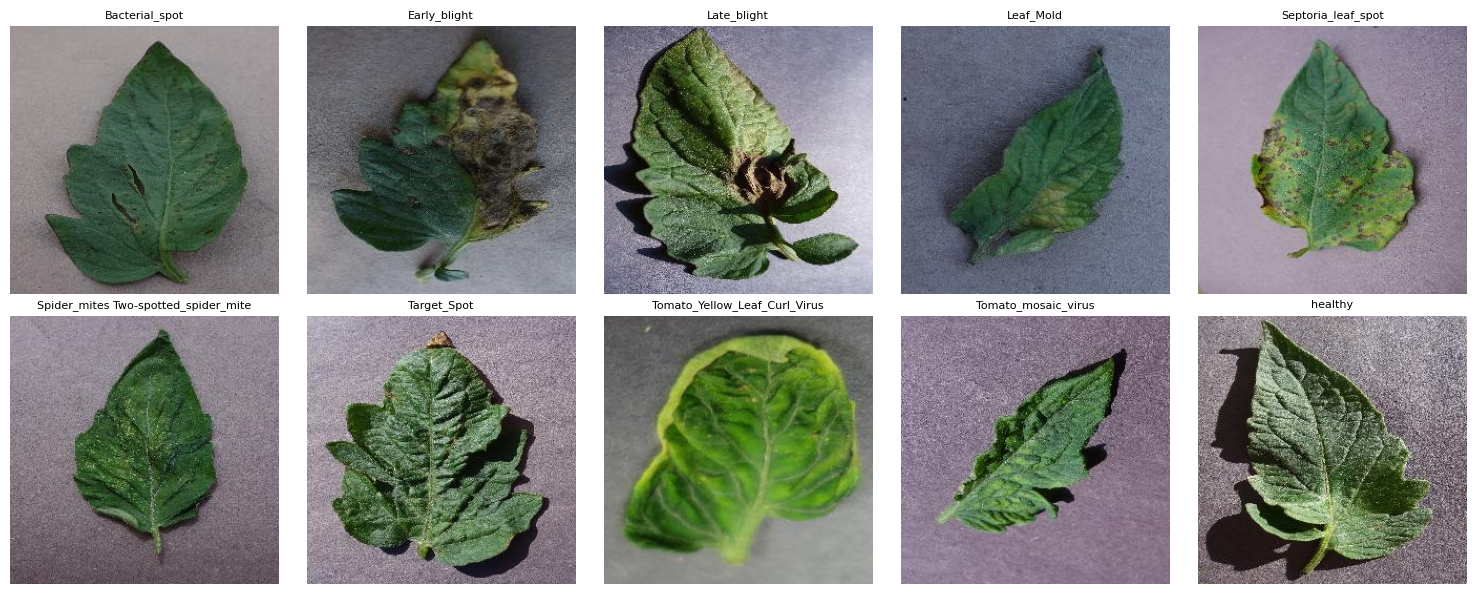

In [5]:
plt.figure(figsize=(15, 6))

for i, c in enumerate(tomato_classes):
    first_image = os.listdir(os.path.join(DATA_DIR, c))[0]
    img = plt.imread(os.path.join(DATA_DIR, c, first_image))
    plt.subplot(2, (len(tomato_classes) + 1) // 2, i + 1)
    plt.imshow(img)
    plt.title(c.replace("Tomato___", ""), fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    os.path.join(WORK_DIR, "train"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True, seed=42
)
val_ds = keras.utils.image_dataset_from_directory(
    os.path.join(WORK_DIR, "val"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)
test_ds = keras.utils.image_dataset_from_directory(
    os.path.join(WORK_DIR, "test"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# prefetch makes training faster
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

Found 12707 files belonging to 10 classes.
Found 2719 files belonging to 10 classes.
Found 2734 files belonging to 10 classes.
Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


## transfer learning with MobileNetV2

The model has four parts:

1. **Data augmentation:** randomly flips, rotates and zooms images during training, so the model learns the disease and not the exact position of the leaf. This helps prevent overfitting.
2. **Rescaling:** converts pixel values from 0–255 to -1 to 1, which is what MobileNetV2 expects.
3. **MobileNetV2 base (frozen):** the pre-trained part that extracts features such as edges, spots and textures. We **freeze** it so its weights don't change.
4. **New classification head:** a small layer that we train to recognise our tomato classes.

In [7]:
# 1. Data augmentation (only active during training)
augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augmentation")

# 2. Rescaling: 0-255  ->  -1 to 1
rescale = layers.Rescaling(1.0 / 127.5, offset=-1)

# 3. Pre-trained MobileNetV2 base (frozen)
base_model = keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

# 4. New classification head
pooling = layers.GlobalAveragePooling2D()
dropout = layers.Dropout(0.2)
classifier = layers.Dense(num_classes, activation="softmax")

# Put everything together
inputs = keras.Input(shape=IMG_SIZE + (3,))
x = augmentation(inputs)
x = rescale(x)
x = base_model(x, training=False)
x = pooling(x)
x = dropout(x)
outputs = classifier(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

9406464/9406464 [==============================] - 1s 0us/step
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 augmentation (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                

In [8]:
EPOCHS = 5

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=2,
    restore_best_weights=True,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop],
)

Epoch 1/5
  1/398 [..............................] - ETA: 45:05 - loss: 2.5370 - accuracy: 0.2500

I0000 00:00:1790289106.952469     116 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


398/398 [==============================] - 32s 62ms/step - loss: 0.8177 - accuracy: 0.7314 - val_loss: 0.5176 - val_accuracy: 0.8352
Epoch 2/5
398/398 [==============================] - 22s 55ms/step - loss: 0.4651 - accuracy: 0.8496 - val_loss: 0.4084 - val_accuracy: 0.8720
Epoch 3/5
398/398 [==============================] - 22s 55ms/step - loss: 0.3997 - accuracy: 0.8697 - val_loss: 0.3557 - val_accuracy: 0.8919
Epoch 4/5
398/398 [==============================] - 22s 56ms/step - loss: 0.3558 - accuracy: 0.8786 - val_loss: 0.3351 - val_accuracy: 0.8933
Epoch 5/5
398/398 [==============================] - 22s 56ms/step - loss: 0.3410 - accuracy: 0.8867 - val_loss: 0.3266 - val_accuracy: 0.8989


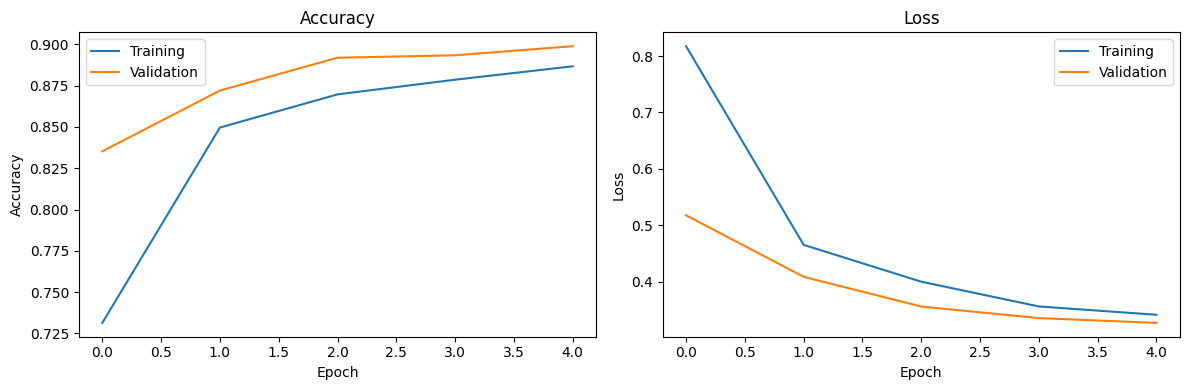

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}")

# Collect true labels and predictions
y_true = []
y_pred = []
for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

short_names = [c.replace("Tomato___", "") for c in class_names]

print(classification_report(y_true, y_pred, labels=range(num_classes), target_names=short_names, digits=3))

86/86 [==============================] - 5s 53ms/step - loss: 0.3297 - accuracy: 0.8939
Test accuracy: 0.8939
                                      precision    recall  f1-score   support

                      Bacterial_spot      0.892     0.928     0.910       320
                        Early_blight      0.886     0.520     0.655       150
                         Late_blight      0.941     0.892     0.916       287
                           Leaf_Mold      0.841     0.882     0.861       144
                  Septoria_leaf_spot      0.840     0.824     0.832       267
Spider_mites Two-spotted_spider_mite      0.761     0.909     0.828       252
                         Target_Spot      0.742     0.816     0.778       212
       Tomato_Yellow_Leaf_Curl_Virus      0.986     0.978     0.982       805
                 Tomato_mosaic_virus      1.000     0.702     0.825        57
                             healthy      0.926     0.988     0.956       240

                            ac

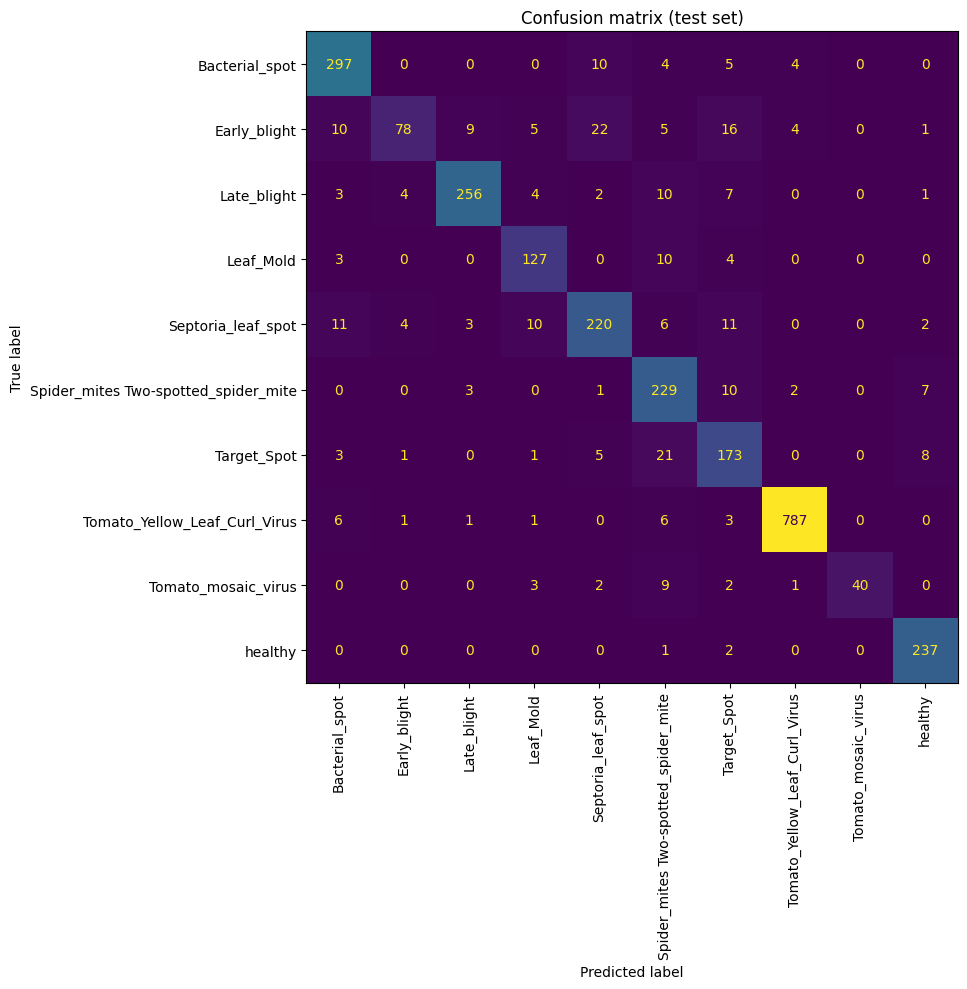

In [11]:
cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))

fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay(cm, display_labels=short_names).plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()

Accuracy tells us *how often* the model is right. **Grad-CAM** shows us *why*: it creates a heatmap of the regions of the image that most influenced the prediction.

- **Red/yellow** = areas the model paid most attention to
- **Blue** = areas it mostly ignored

A trustworthy model should focus on the **diseased spots on the leaf**, not on the background. This is an important idea in ethical and responsible AI: we should be able to check that a model is making decisions for the right reasons.

**How it works (simple version):** we take the feature maps from the last layer of MobileNetV2, measure how much each feature map affects the predicted class (using gradients), and combine them into one heatmap.

In [12]:
def make_gradcam(image):
    # image: one image with pixel values 0-255, shape (224, 224, 3)
    img = tf.expand_dims(tf.cast(image, tf.float32), axis=0)   # add batch dimension
    img = rescale(img)                                         # same scaling as the model

    with tf.GradientTape() as tape:
        feature_maps = base_model(img, training=False)         # last conv layer output (7x7x1280)
        tape.watch(feature_maps)
        predictions = classifier(pooling(feature_maps))
        predicted_class = tf.argmax(predictions[0])
        class_score = predictions[:, predicted_class]

    # how much each feature map affects the predicted class
    gradients = tape.gradient(class_score, feature_maps)
    weights = tf.reduce_mean(gradients, axis=(0, 1, 2))

    # weighted combination of feature maps = heatmap
    heatmap = tf.reduce_sum(feature_maps[0] * weights, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)

    # resize the 7x7 heatmap to the image size
    heatmap = tf.image.resize(heatmap[..., tf.newaxis], IMG_SIZE)[..., 0]
    return heatmap.numpy(), int(predicted_class)

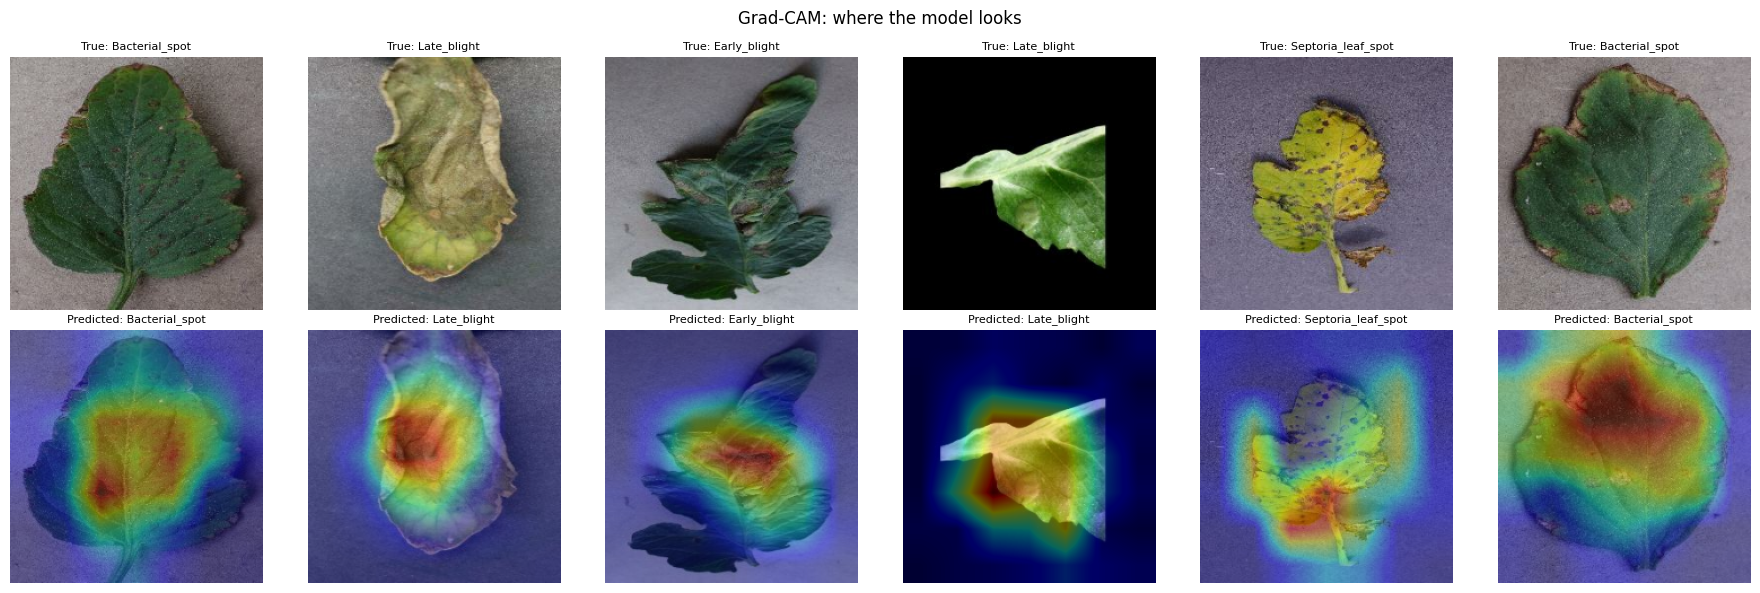

In [13]:
test_shuffled = test_ds.unbatch().shuffle(1000, seed=1).batch(32)   # mix classes so we see different diseases
images, labels = next(iter(test_shuffled))

plt.figure(figsize=(18, 6))
for i in range(6):
    image = images[i].numpy()
    heatmap, predicted = make_gradcam(image)

    true_name = short_names[labels[i].numpy()]
    predicted_name = short_names[predicted]

    plt.subplot(2, 6, i + 1)
    plt.imshow(image.astype("uint8"))
    plt.title(f"True: {true_name}", fontsize=8)
    plt.axis("off")

    plt.subplot(2, 6, i + 7)
    plt.imshow(image.astype("uint8"))
    plt.imshow(heatmap, cmap="jet", alpha=0.4)
    plt.title(f"Predicted: {predicted_name}", fontsize=8)
    plt.axis("off")

plt.suptitle("Grad-CAM: where the model looks")
plt.tight_layout()
plt.show()

Wrong predictions found: 6


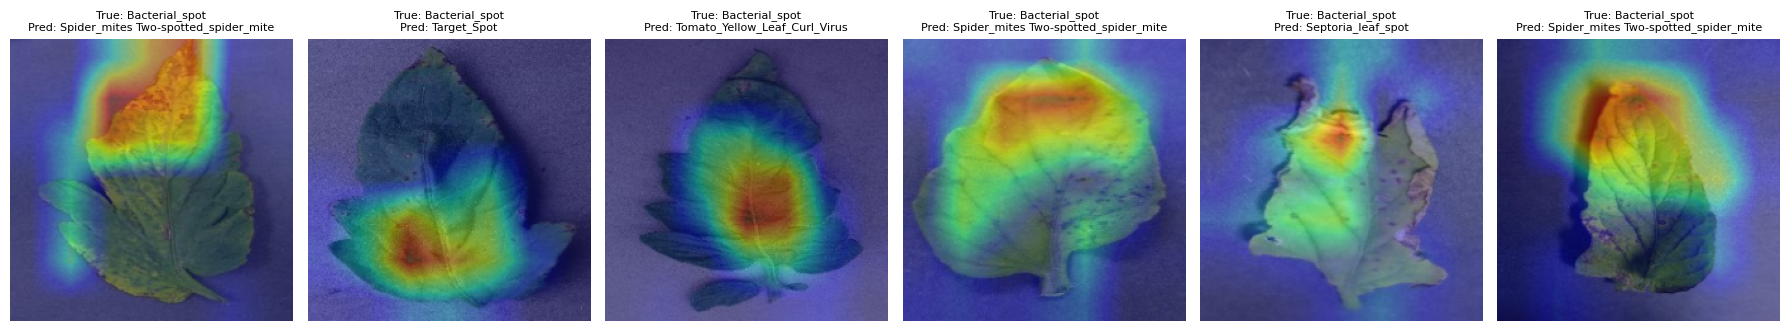

In [14]:
wrong_images, wrong_true, wrong_pred = [], [], []

for images, labels in test_ds:
    preds = np.argmax(model.predict(images, verbose=0), axis=1)
    for img, t, p in zip(images, labels.numpy(), preds):
        if t != p:
            wrong_images.append(img.numpy())
            wrong_true.append(t)
            wrong_pred.append(p)
    if len(wrong_images) >= 6:
        break

print("Wrong predictions found:", len(wrong_images))

n = min(6, len(wrong_images))
plt.figure(figsize=(18, 3.5))
for i in range(n):
    heatmap, _ = make_gradcam(wrong_images[i])
    plt.subplot(1, 6, i + 1)
    plt.imshow(wrong_images[i].astype("uint8"))
    plt.imshow(heatmap, cmap="jet", alpha=0.4)
    plt.title(f"True: {short_names[wrong_true[i]]}\nPred: {short_names[wrong_pred[i]]}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [15]:
base_model.trainable = True

# keep most layers frozen, only unfreeze the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),   # very small learning rate
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=[early_stop],
)

Epoch 1/3
398/398 [==============================] - 35s 68ms/step - loss: 0.2847 - accuracy: 0.9022 - val_loss: 0.2969 - val_accuracy: 0.9022
Epoch 2/3
398/398 [==============================] - 26s 66ms/step - loss: 0.2353 - accuracy: 0.9202 - val_loss: 0.2253 - val_accuracy: 0.9224
Epoch 3/3
398/398 [==============================] - 26s 65ms/step - loss: 0.2009 - accuracy: 0.9306 - val_loss: 0.2098 - val_accuracy: 0.9250


In [16]:
model.save("/kaggle/working/tomato_disease_mobilenetv2.keras")

report = classification_report(y_true, y_pred, labels=range(num_classes), target_names=short_names, output_dict=True)
pd.DataFrame(report).transpose().to_csv("/kaggle/working/classification_report.csv")

print("Saved model and classification report.")
print(f"Final test accuracy: {test_accuracy:.4f}")
print(f"Macro F1-score: {report['macro avg']['f1-score']:.4f}")

Saved model and classification report.
Final test accuracy: 0.8939
Macro F1-score: 0.8542


In [17]:
shutil.rmtree(WORK_DIR, ignore_errors=True)
print("Temporary image folder removed.")

Temporary image folder removed.
